# Task 07 - Baseline Target Feature Engineering

## Objective
Engineer meaningful features, train a model, inspect feature importance, check for leakage, and finalize the baseline feature set.

In [4]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project Root:", project_root)

Project Root: /home/akash/Projects/Altrodav


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from src.data import load_data, split_data
from src.model import train_model
from src.evaluate import evaluate_model

In [6]:
df = load_data()

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
print("Target Column:", df.columns[-1])

print("\nClass Distribution:")
print(df["target"].value_counts())

Target Column: target

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [8]:
df["sepal_area"] = (
    df["sepal length (cm)"] *
    df["sepal width (cm)"]
)

df["petal_area"] = (
    df["petal length (cm)"] *
    df["petal width (cm)"]
)

df["sepal_ratio"] = (
    df["sepal length (cm)"] /
    df["sepal width (cm)"]
)

df["petal_ratio"] = (
    df["petal length (cm)"] /
    df["petal width (cm)"]
)

print("New Features Added Successfully!")

df.head()

New Features Added Successfully!


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,sepal_area,petal_area,sepal_ratio,petal_ratio
0,5.1,3.5,1.4,0.2,0,17.85,0.28,1.457143,7.0
1,4.9,3.0,1.4,0.2,0,14.70,0.28,1.633333,7.0
2,4.7,3.2,1.3,0.2,0,15.04,0.26,1.468750,6.5
3,4.6,3.1,1.5,0.2,0,14.26,0.30,1.483871,7.5
4,5.0,3.6,1.4,0.2,0,18.00,0.28,1.388889,7.0


In [9]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

print("Training Set :", X_train.shape)
print("Validation Set:", X_val.shape)
print("Test Set :", X_test.shape)

Training Set : (105, 8)
Validation Set: (22, 8)
Test Set : (23, 8)


In [10]:
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_val = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model = train_model(
    model,
    X_train,
    y_train
)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [12]:
accuracy = evaluate_model(
    model,
    X_val,
    y_val
)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.8636


In [13]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,petal_area,0.272643
2,petal length (cm),0.247756
3,petal width (cm),0.222602
7,petal_ratio,0.092091
6,sepal_ratio,0.075081
0,sepal length (cm),0.056151
4,sepal_area,0.021645
1,sepal width (cm),0.012032


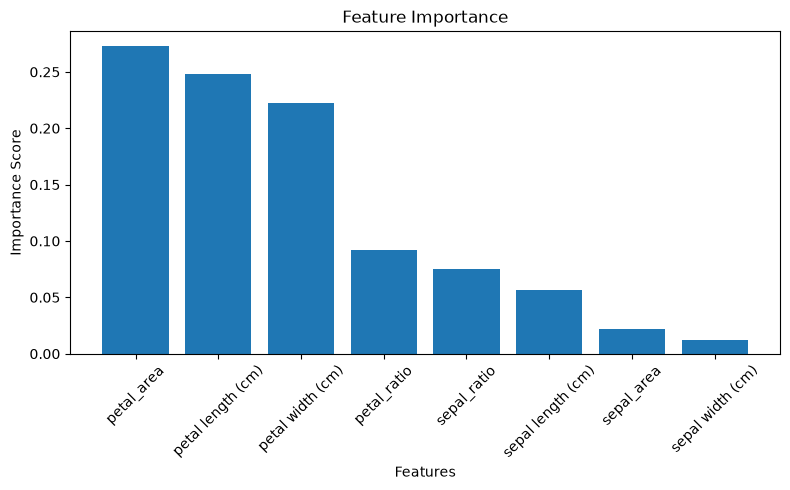

In [14]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [15]:
print("========== LEAKAGE CHECK ==========")

print("✓ Target column not used as a feature.")

print("✓ Engineered features use only existing measurements.")

print("✓ Feature scaling fitted only on training data.")

print("✓ Validation and Test sets remained unseen.")

print("\nLeakage Status : PASSED")

========== LEAKAGE CHECK ==========
✓ Target column not used as a feature.
✓ Engineered features use only existing measurements.
✓ Feature scaling fitted only on training data.
✓ Validation and Test sets remained unseen.

Leakage Status : PASSED


In [16]:
print("========== BASELINE FEATURE SET ==========\n")

for feature in importance["Feature"]:
    print(feature)

========== BASELINE FEATURE SET ==========

petal_area
petal length (cm)
petal width (cm)
petal_ratio
sepal_ratio
sepal length (cm)
sepal_area
sepal width (cm)


In [17]:
import os

os.makedirs("../logs", exist_ok=True)

importance.to_csv(
    "../logs/task07_feature_importance.csv",
    index=False
)

print("Feature Importance CSV Saved Successfully!")

Feature Importance CSV Saved Successfully!


In [18]:
print("=" * 45)

print("TASK 07 SUMMARY")

print("=" * 45)

print(f"Validation Accuracy : {accuracy:.4f}")

print(f"Total Features : {len(importance)}")

print("Leakage Check : PASSED")

print("Feature Importance File Saved")

print("\nTask 07 Completed Successfully!")

TASK 07 SUMMARY
Validation Accuracy : 0.8636
Total Features : 8
Leakage Check : PASSED
Feature Importance File Saved

Task 07 Completed Successfully!
